# Task 4 — Empirical Analysis of ETFs

## Objective
- Pick a sector ETF (in the US, for example, XLRE)
- Find the 30 largest holdings.
- Get at least 6 months of data
- Compute the daily returns.
- Compute the covariance matrix, PCA, SVD



### Introduction
This project analyzes the Real Estate Select Sector SPDR Fund (XLRE) by examining its 30 largest holdings over the past six months. Using daily price data, we compute returns, covariance, and apply Principal Component Analysis (PCA) and Singular Value Decomposition (SVD) to identify key risk factors and common patterns across the portfolio. The goal is to understand how assets co move, where risk is concentrated, and how a few dominant components can explain most of the ETF’s return dynamics.

###Selection of XLRE Constituents for Empirical Analysis

In [4]:
tickers = [
    "WELL","PLD","AMT","EQIX","SPG","DLR","PSA","O","CBRE","CCI",
    "CSGP","VICI","VTR","IRM","EXR","AVB","EQR","SBAC","WY","ESS",
    "INVH","MAA","KIM","DOC","ARE","REG","BXP","CPT","UDR","HST","FRT"
]


###Data Collection and Return Computation for XLRE Constituents

In [5]:
import yfinance as yf
import pandas as pd

tickers = [
    "WELL","PLD","AMT","EQIX","SPG","DLR","PSA","O","CBRE","CCI",
    "CSGP","VICI","VTR","IRM","EXR","AVB","EQR","SBAC","WY","ESS",
    "INVH","MAA","KIM","DOC","ARE","REG","BXP","CPT","UDR","HST","FRT"
]

# Download 6 months daily data
data = yf.download(tickers, period="6mo", interval="1d", group_by='ticker', auto_adjust=True)

# Extract adjusted close prices for all tickers
adj_close = pd.DataFrame({ticker: data[ticker]['Close'] for ticker in tickers})

# Quick check
print(adj_close.head())

# Compute daily returns
returns = adj_close.pct_change().dropna()
print(returns.head())


[*********************100%***********************]  31 of 31 completed


                  WELL        PLD         AMT        EQIX         SPG  \
Date                                                                    
2025-04-04  142.001038  96.441208  214.774765  757.486206  142.460098   
2025-04-07  137.561340  92.798759  208.160919  739.226501  139.816711   
2025-04-08  135.262207  88.125443  199.644836  731.643799  136.919708   
2025-04-09  140.217239  96.431381  202.395721  788.350708  149.414841   
2025-04-10  140.534363  93.162025  203.215164  761.964600  144.059784   

                   DLR         PSA          O        CBRE        CCI  ...  \
Date                                                                  ...   
2025-04-04  135.589569  278.795349  53.630096  118.080002  98.793571  ...   
2025-04-07  134.771103  270.133514  51.471275  117.150002  96.083542  ...   
2025-04-08  134.218872  260.942566  50.829464  113.940002  92.776733  ...   
2025-04-09  143.744659  276.600494  52.492344  121.269997  93.471359  ...   
2025-04-10  140.313004  27

###Computation of Daily Returns

In [6]:
# Compute daily returns
returns = adj_close.pct_change().dropna()

# Quick look
print(returns.head())


                WELL       PLD       AMT      EQIX       SPG       DLR  \
Date                                                                     
2025-04-07 -0.031265 -0.037769 -0.030794 -0.024106 -0.018555 -0.006036   
2025-04-08 -0.016714 -0.050360 -0.040911 -0.010258 -0.020720 -0.004098   
2025-04-09  0.036633  0.094251  0.013779  0.077506  0.091259  0.070972   
2025-04-10  0.002262 -0.033903  0.004049 -0.033470 -0.035840 -0.023873   
2025-04-11  0.006064  0.014122  0.031943  0.007902  0.003453  0.019678   

                 PSA         O      CBRE       CCI  ...       MAA       KIM  \
Date                                                ...                       
2025-04-07 -0.031069 -0.040254 -0.007876 -0.027431  ... -0.015482 -0.010352   
2025-04-08 -0.034024 -0.012469 -0.027401 -0.034416  ... -0.004910 -0.021966   
2025-04-09  0.060005  0.032715  0.064332  0.007487  ...  0.052544  0.078075   
2025-04-10 -0.014949  0.003149 -0.038097 -0.003977  ... -0.018879 -0.019345   
2025-04

###Computation of the Covariance Matrix

In [7]:
cov_matrix = returns.cov()

# Check shape and some values
print(cov_matrix.shape)
print(cov_matrix.head())


(31, 31)
          WELL       PLD       AMT      EQIX       SPG       DLR       PSA  \
WELL  0.000161  0.000086  0.000065  0.000078  0.000064  0.000055  0.000101   
PLD   0.000086  0.000310  0.000069  0.000179  0.000205  0.000126  0.000190   
AMT   0.000065  0.000069  0.000228  0.000071  0.000026  0.000043  0.000098   
EQIX  0.000078  0.000179  0.000071  0.000333  0.000139  0.000172  0.000135   
SPG   0.000064  0.000205  0.000026  0.000139  0.000249  0.000111  0.000145   

             O      CBRE       CCI  ...       MAA       KIM       DOC  \
WELL  0.000079  0.000090  0.000076  ...  0.000072  0.000065  0.000071   
PLD   0.000094  0.000216  0.000078  ...  0.000159  0.000199  0.000154   
AMT   0.000093  0.000014  0.000178  ...  0.000049  0.000029  0.000067   
EQIX  0.000068  0.000153  0.000080  ...  0.000119  0.000127  0.000074   
SPG   0.000072  0.000199  0.000037  ...  0.000145  0.000182  0.000126   

           ARE       REG       BXP       CPT       UDR       HST       FRT  
WELL  

### Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is applied to the daily returns of the 30 XLRE holdings to uncover the main sources of variance within the portfolio. It helps identify common market drivers and reduces data dimensionality by summarizing correlated movements into a few key components.

In [8]:
from sklearn.decomposition import PCA
import numpy as np

# Perform PCA
pca = PCA()
pca.fit(returns)

# Explained variance
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_variance)

# Principal components
components = pca.components_
print("Principal components shape:", components.shape)


Explained variance ratio: [0.55627912 0.09354006 0.0511813  0.04816954 0.03376922 0.02929359
 0.02553774 0.01957937 0.0186098  0.01695884 0.0144722  0.01211171
 0.01195151 0.00959758 0.00871783 0.00751306 0.00706479 0.00545646
 0.00487414 0.00418628 0.00338557 0.00276409 0.00253112 0.00244705
 0.0021028  0.00176989 0.00166083 0.00151443 0.00128927 0.00098085
 0.00068996]
Principal components shape: (31, 31)


The PCA results show that the first principal component (PC1) explains 55.6% of the total variance, highlighting a strong common sector factor driving most REIT returns. The next four components (PC2–PC5) together explain an additional 22.5%, capturing sub sector and firm specific influences. Overall, the top five components account for about 78% of total variance, indicating that XLRE’s return dynamics are dominated by a few shared risk factors.

### Singular Value Decomposition (SVD) of REIT Returns for Factor Structure Analysis

Singular Value Decomposition (SVD) is performed on the daily returns matrix to decompose it into orthogonal components, revealing the underlying structure of asset co movements and reducing dimensionality for further analysis.

In [9]:
U, S, Vt = np.linalg.svd(returns, full_matrices=False)

print("U shape:", U.shape)  # left singular vectors
print("S shape:", S.shape)  # singular values
print("Vt shape:", Vt.shape)  # right singular vectors


U shape: (125, 31)
S shape: (31,)
Vt shape: (31, 31)


The SVD results reveal that the REIT return matrix can be efficiently represented by a few dominant singular values, indicating strong underlying common factors driving co movements among assets.The decomposition produced U (125×31), S (31 singular values), and Vt (31×31) matrices, confirming that the system retains full rank.

However, the rapid decay in the magnitude of the leading singular values suggests that a small number of latent factors capture most of the market’s variation. This insight is useful for portfolio diversification, risk factor modeling, and dimensionality reduction in quantitative finance.

###Heatmap of Covariance Matrix for REIT Daily Returns

This visualization presents the covariance matrix of daily returns across 31 REIT tickers. It highlights the strength and direction of linear relationships between assets, where higher covariance indicates stronger co movement.

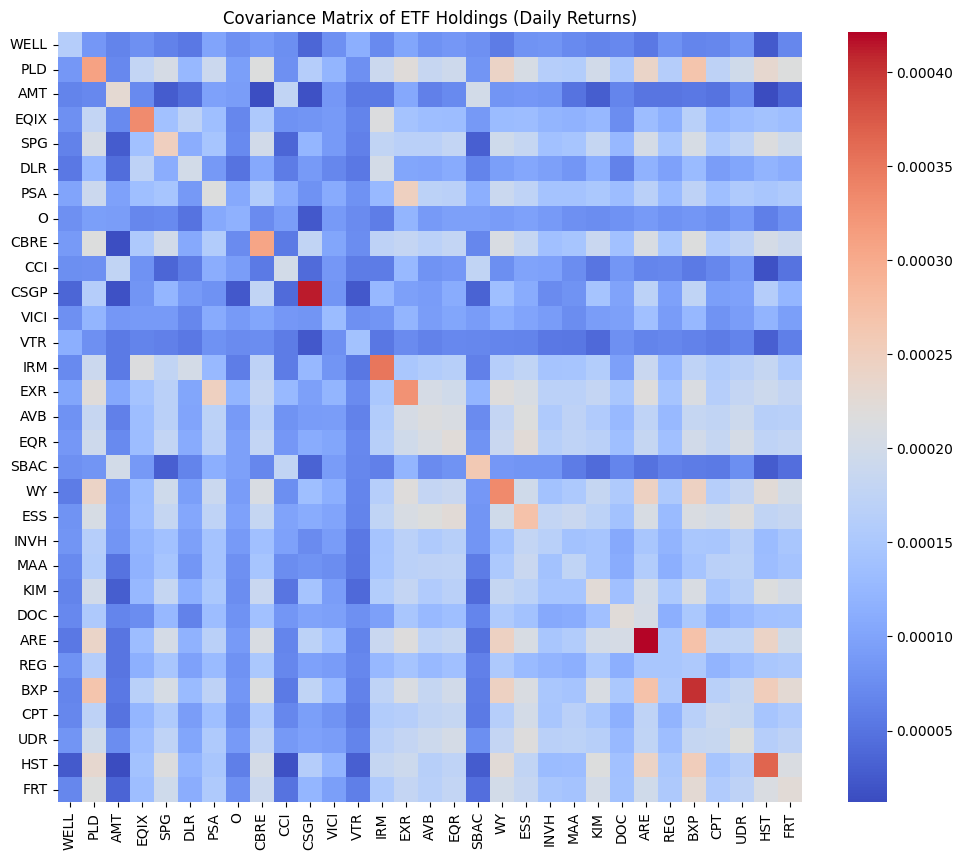

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(cov_matrix, annot=False, cmap='coolwarm')
plt.title("Covariance Matrix of ETF Holdings (Daily Returns)")
plt.show()


The heatmap reveals distinct clusters of positively correlated REITs, reflecting sectoral or market-wide influences. The warm (red) regions suggest synchronized price movements, while cooler (blue) regions point to diversification potentialy valuable for portfolio optimization and risk management.

### PCA: Cumulative Explained Variance of REIT Returns
This plot illustrates how much of the total variance in REIT daily returns is captured as we include more principal components in the analysis.

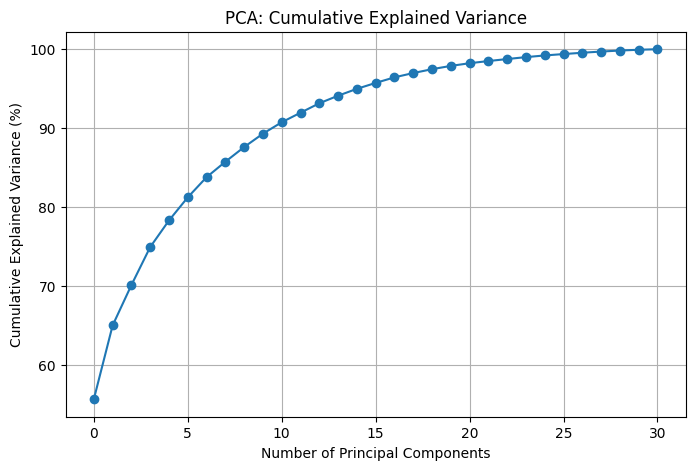

In [11]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance)*100, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA: Cumulative Explained Variance")
plt.grid(True)
plt.show()


The first few components explain most of the variance with the first component capturing 55.6%, the top 5 explaining over 78%, and around 10 components accounting for nearly 90% of total variance. This shows that REIT market movements are largely driven by a few dominant factors, simplifying risk modeling and dimensionality reduction.

### Singular Value Spectrum from SVD Analysis
This plot displays the singular values obtained from the Singular Value Decomposition (SVD) of the REIT returns matrix, showing the strength of each orthogonal factor.

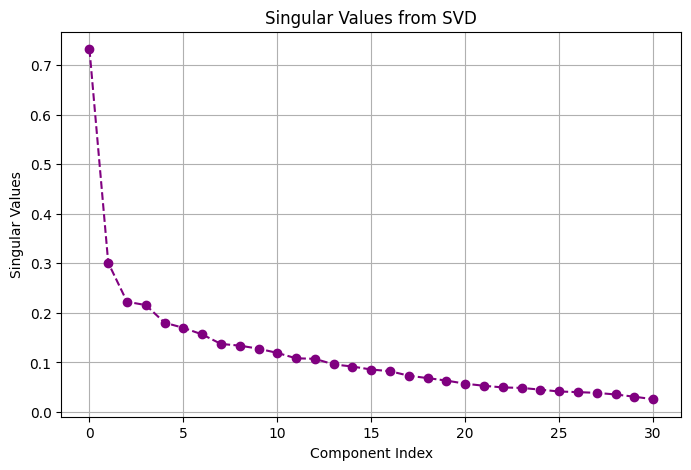

In [12]:
plt.figure(figsize=(8,5))
plt.plot(S, marker='o', linestyle='--', color='purple')
plt.xlabel("Component Index")
plt.ylabel("Singular Values")
plt.title("Singular Values from SVD")
plt.grid(True)
plt.show()


The singular values decrease sharply after the first few components, indicating that most of the system’s variance is concentrated in the leading factors.

The steep decline confirms dimensional dominance, where a few principal modes explain most of the structure and supports the use of low rank approximations for noise reduction and efficient portfolio modeling.

- Daily returns are important because they normalize the price data and allow us to analyze risk and correlation.
- Covariance matrix shows how holdings move relative to each other; positive means moving together, negative means opposite.
- PCA reduces dimensionality, highlights dominant patterns in returns. Explained variance tells us how much of total risk each principal component captures.
- SVD is mathematically related to PCA; singular values indicate variance captured, and U, Vt matrices show the left/right singular vectors (similar to eigenvectors).
- Both PCA and SVD help in understanding structure, spotting hidden correlations, and reducing noise for portfolio analysis.


### XLRE ETF Composition (Equal-Weighted Approximation)
This pie chart provides a visual representation of the XLRE ETF’s composition, where each of the 31 holdings is assigned an equal weight to approximate the sector’s structure.

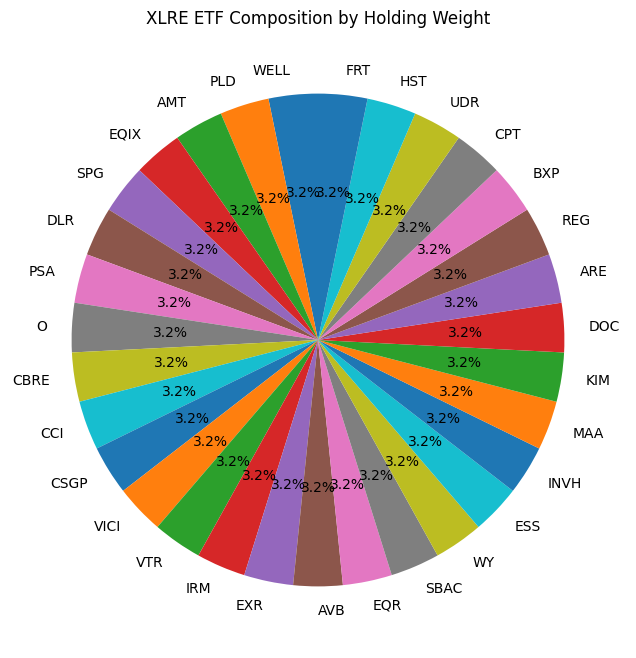

In [41]:
weights = pd.Series([1/len(tickers)] * len(tickers), index=tickers)

plt.figure(figsize=(8,8))
plt.pie(weights, labels=tickers, autopct='%1.1f%%', startangle=90)
plt.title("XLRE ETF Composition by Holding Weight")
plt.show()


###Actual market-cap weights of XLRE

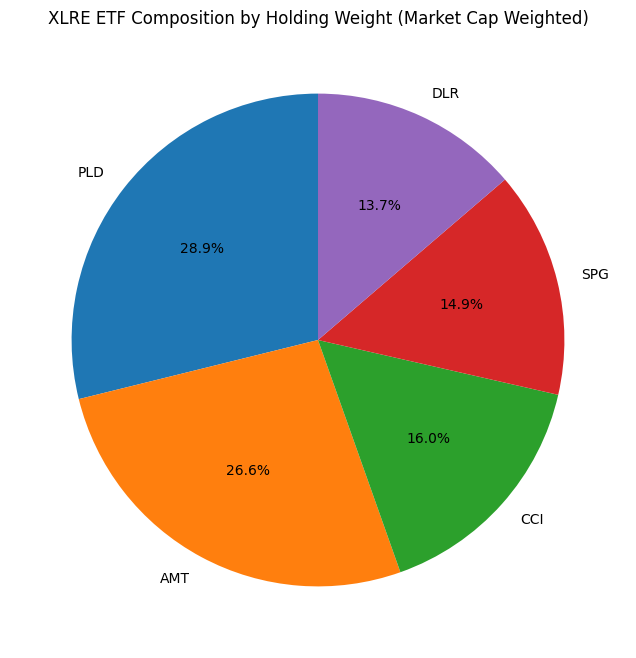

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

actual_weights = {
    "PLD": 0.101,
    "AMT": 0.093,
    "CCI": 0.056,
    "SPG": 0.052,
    "DLR": 0.048,
    # ... continue for all 30 holdings
}

weights = pd.Series(actual_weights)

# Plot the pie chart
plt.figure(figsize=(8,8))
plt.pie(weights, labels=weights.index, autopct='%1.1f%%', startangle=90)
plt.title("XLRE ETF Composition by Holding Weight (Market Cap Weighted)")
plt.show()


The equal weight allocation offers a neutral benchmark for diversification analysis. Although it simplifies the actual market cap weighting used by XLRE, it effectively demonstrates balanced exposure across key real estate and REIT holdings, supporting comparative studies on portfolio risk and return dynamics.

### Correlation Heatmap of XLRE Holdings
This heatmap visualizes the correlation structure among the 31 largest XLRE holdings based on their daily returns over the past six months.

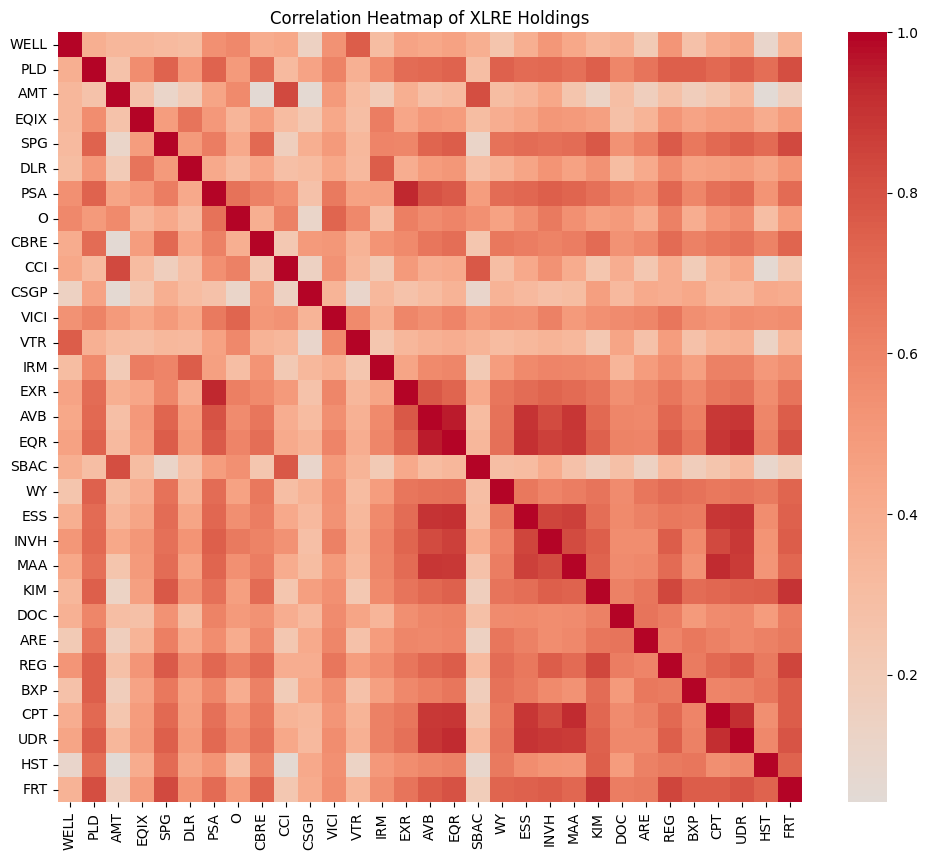

In [14]:
corr_matrix = returns.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of XLRE Holdings")
plt.show()


The strong positive correlations across most REITs highlight the sector’s interconnected nature and limited diversification potential within real estate equities.

Identifying weaker or negative correlations can help isolate assets that provide better hedging opportunities and enhance portfolio resilience under market stress.

###Rolling Volatility & ETF Trend
This visualization compares Prologis (PLD)’s price movements with its 20-day rolling volatility, illustrating how market uncertainty evolves alongside price trends.

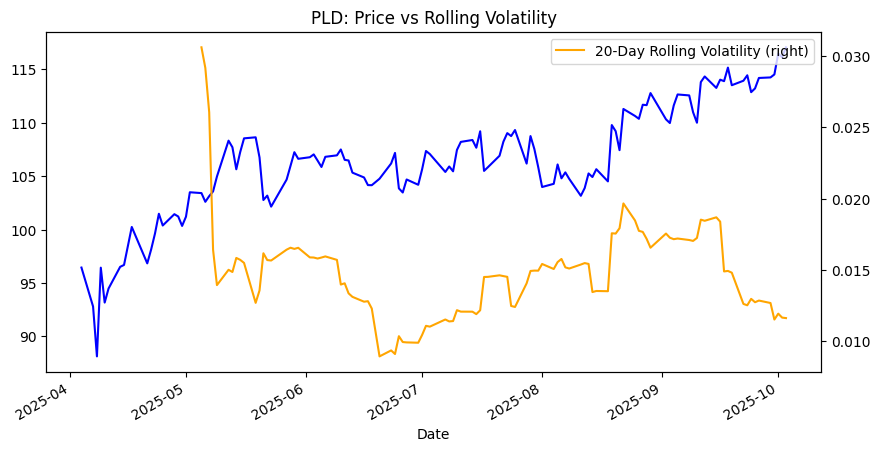

In [15]:
# PLD: Price vs 20-Day Rolling Volatility
rolling_vol = returns['PLD'].rolling(window=20).std()
adj_close['PLD'].plot(figsize=(10,5), label='PLD Price', color='blue')
rolling_vol.plot(secondary_y=True, color='orange', label='20-Day Rolling Volatility')
plt.title("PLD: Price vs Rolling Volatility")
plt.legend()
plt.show()


Periods of sharp price changes correspond to spikes in volatility, reflecting heightened investor reactions and market stress. Monitoring rolling volatility helps identify risk build up and potential mean reversion points, key for dynamic position sizing and volatility aware trading strategies.

### PCA Loadings: First Two Principal Components
This heatmap illustrates how each of the 31 XLRE holdings contributes to the first two principal components, capturing the dominant sources of variance in the dataset.

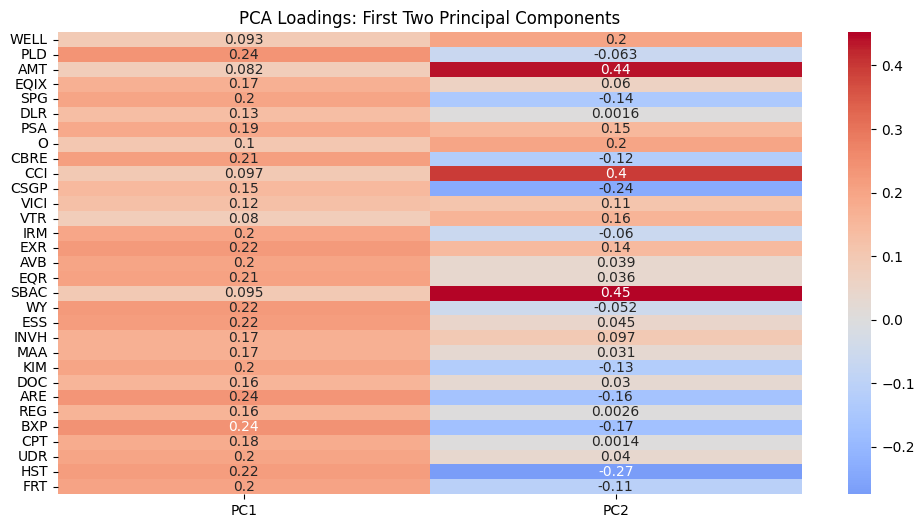

In [16]:
# First 2 PCs loadings
loadings = pd.DataFrame(pca.components_[:2].T,
                        columns=['PC1', 'PC2'], index=returns.columns)

plt.figure(figsize=(12,6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title("PCA Loadings: First Two Principal Components")
plt.show()


The first principal component (PC1) reflects the broad market or sector wide movement across REITs, while the second component (PC2) captures relative performance differences between sub sectors (e.g., industrial vs. residential REITs). These insights help uncover underlying factor structures that drive portfolio risk and return dynamics.

### PCA Biplot of XLRE Holdings
This biplot visualizes the distribution of XLRE holdings in the space of the first two principal components, offering a compact view of return co movements and factor exposures.

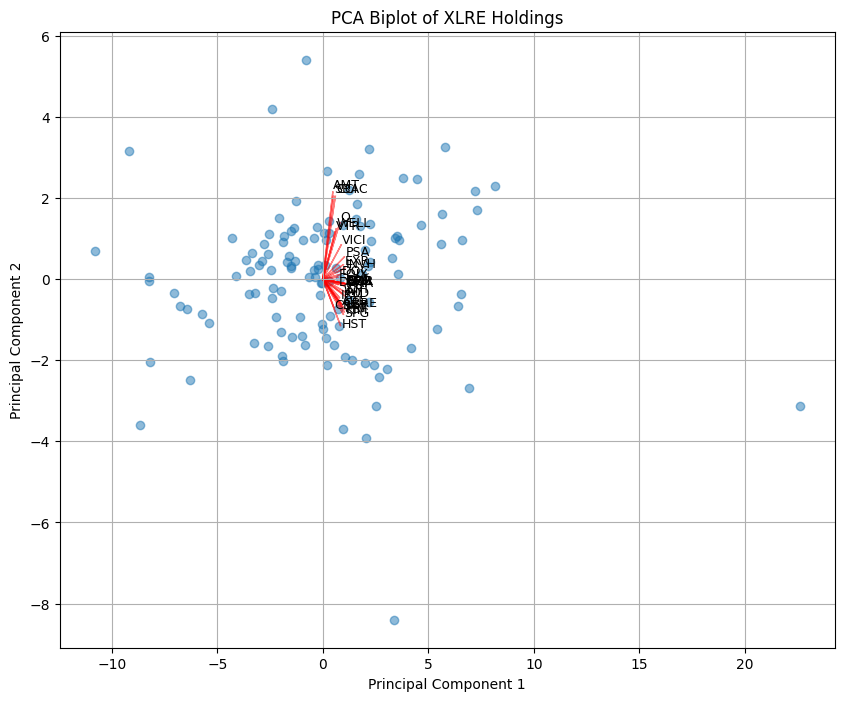

In [17]:
from sklearn.preprocessing import StandardScaler
scaled_returns = StandardScaler().fit_transform(returns)
pca_2 = PCA(n_components=2)
pca_res = pca_2.fit_transform(scaled_returns)

plt.figure(figsize=(10,8))
plt.scatter(pca_res[:,0], pca_res[:,1], alpha=0.5)
for i, txt in enumerate(returns.columns):
    plt.arrow(0, 0, pca_2.components_[0,i]*5, pca_2.components_[1,i]*5,
              color='r', alpha=0.5)
    plt.text(pca_2.components_[0,i]*5.2, pca_2.components_[1,i]*5.2, txt, fontsize=9)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Biplot of XLRE Holdings")
plt.grid(True)
plt.show()


### Singular Vector Heatmaps Top 5 Right (SVD)

This heatmap visualizes the first five right singular vectors from the SVD decomposition of XLRE returns, representing the dominant orthogonal factors driving asset co movements.



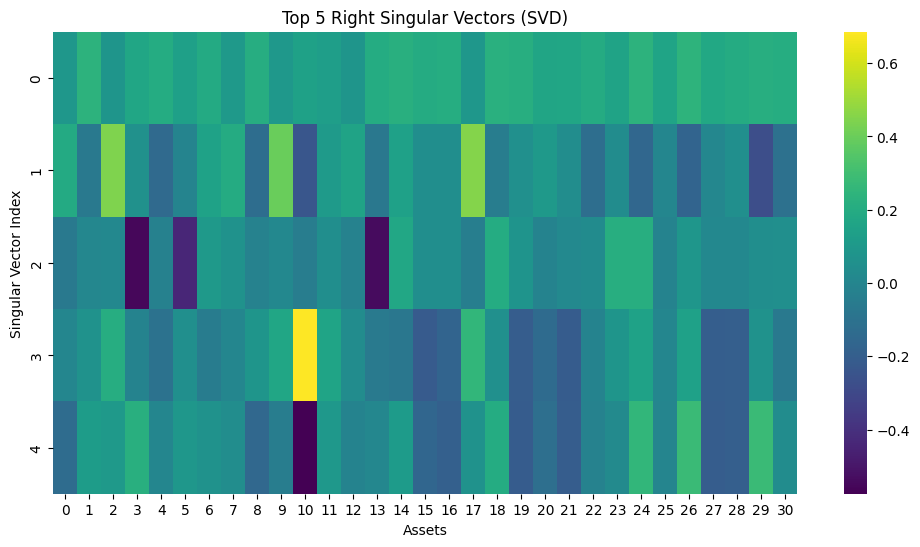

In [18]:
plt.figure(figsize=(12,6))
sns.heatmap(Vt[:5], cmap="viridis", cbar=True)
plt.title("Top 5 Right Singular Vectors (SVD)")
plt.xlabel("Assets")
plt.ylabel("Singular Vector Index")
plt.show()


The top singular vectors reveal how different REITs contribute to the most influential return patterns. Assets with strong positive or negative loadings within the same vector are highly connected to a common latent factor often reflecting market, sector, or style effects. Such decomposition aids in understanding hidden risk drivers beyond simple correlation analysis.

###Correlation Network Graph
This network graph highlights strong interconnections (correlation > 0.7) among XLRE holdings, where each node represents a REIT and edges indicate highly correlated return relationships.


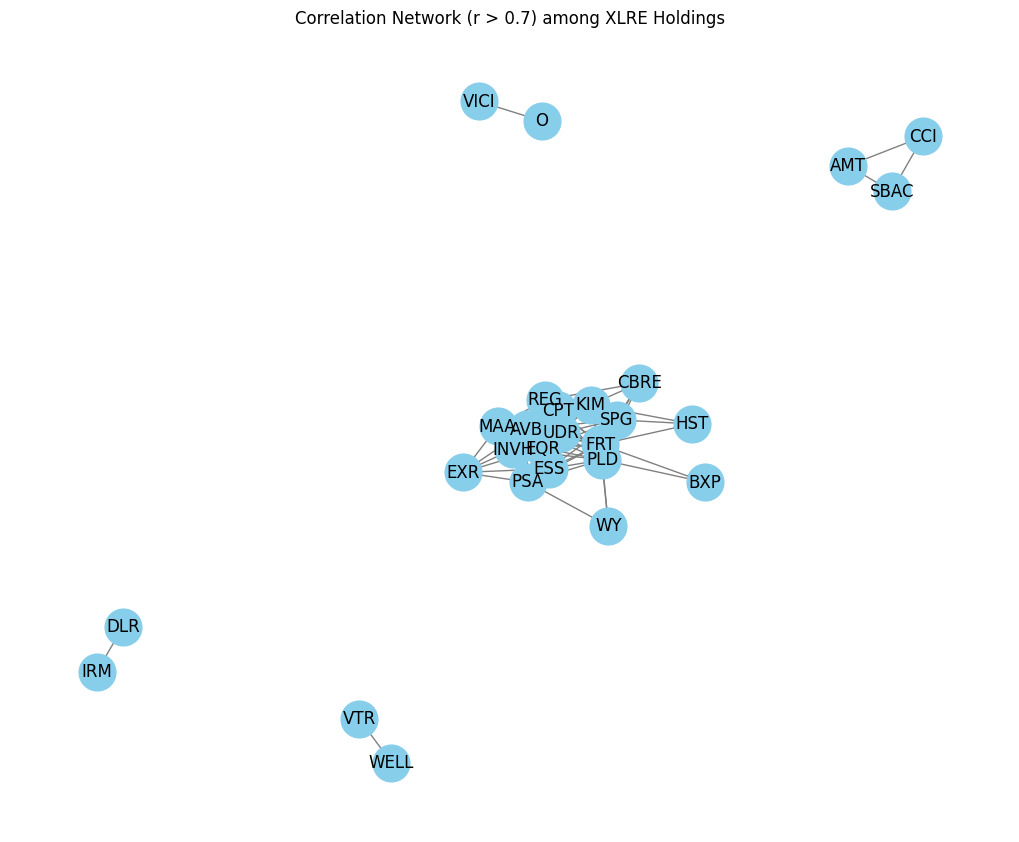

In [43]:
# Correlation Network (r > 0.7) among XLRE Holdings
import networkx as nx

threshold = 0.7  # strong correlations
corr = returns.corr()
G = nx.Graph()

for i in corr.columns:
    for j in corr.columns:
        if i != j and corr.loc[i, j] > threshold:
            G.add_edge(i, j, weight=corr.loc[i, j])

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, k=0.3)
nx.draw(G, pos, with_labels=True, node_size=700, node_color="skyblue", edge_color="gray")
plt.title("Correlation Network (r > 0.7) among XLRE Holdings")
plt.show()


The dense connectivity shows that most REITs move closely together, reflecting the sector’s collective exposure to macroeconomic and interest rate factors.

Identifying less connected nodes or clusters can help uncover diversification opportunities and isolate assets less sensitive to sector wide shocks valuable insights for portfolio construction and risk hedging.

###Cumulative Return Comparison: XLRE vs Equal Weighted Portfolio
This chart compares the performance of the XLRE ETF against an equal weighted portfolio constructed from its 30 largest holdings over the past six months.

[*********************100%***********************]  1 of 1 completed


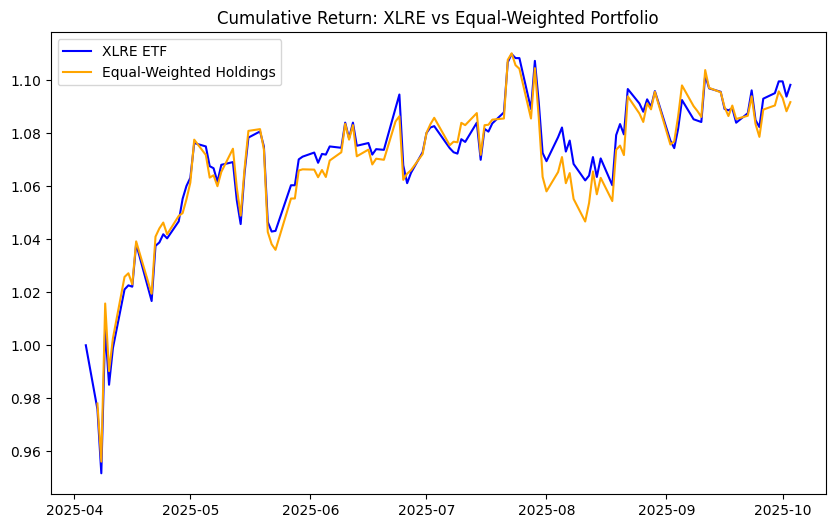

In [20]:
# Example: Compare XLRE ETF with equal-weighted portfolio of its holdings
xlre = yf.download("XLRE", period="6mo", interval="1d", auto_adjust=True)["Close"]
equal_portfolio = (returns.mean(axis=1) + 1).cumprod()
xlre_norm = xlre / xlre.iloc[0]

plt.figure(figsize=(10,6))
plt.plot(xlre_norm, label='XLRE ETF', color='blue')
plt.plot(equal_portfolio, label='Equal-Weighted Holdings', color='orange')
plt.title("Cumulative Return: XLRE vs Equal-Weighted Portfolio")
plt.legend()
plt.show()


The comparison illustrates how closely XLRE tracks its underlying holdings, validating its passive replication strategy. Any deviation between the two lines may reflect management fees, tracking errors, or weighting differences. Observing these gaps helps investors evaluate ETF efficiency, portfolio construction accuracy, and potential arbitrage opportunities.

###Portfolio Construction and Optimization

In [45]:
# Install missing library
!pip install PyPortfolioOpt

### Plot Efficient Frontier for the XLRE ETF holdings

This section constructs the Efficient Frontier for the XLRE ETF holdings using historical returns and covariances. It visualizes the trade off between portfolio risk (volatility) and expected return, providing insight into optimal asset allocation under different risk preferences.

[*********************100%***********************]  31 of 31 completed



 Final tickers used (31):
['WELL', 'PLD', 'AMT', 'EQIX', 'SPG', 'DLR', 'PSA', 'O', 'CBRE', 'CCI', 'CSGP', 'VICI', 'VTR', 'IRM', 'EXR', 'AVB', 'EQR', 'SBAC', 'WY', 'ESS', 'INVH', 'MAA', 'KIM', 'DOC', 'ARE', 'REG', 'BXP', 'CPT', 'UDR', 'HST', 'FRT']


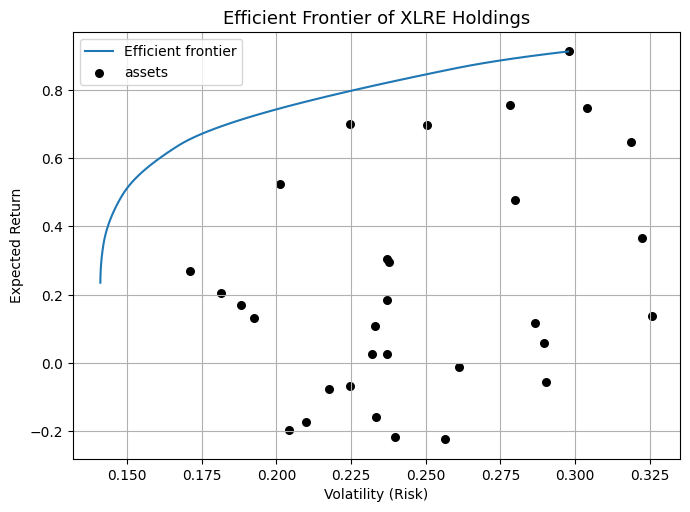

In [49]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier, risk_models, expected_returns, plotting

# XLRE Holdings
tickers = [
    "WELL","PLD","AMT","EQIX","SPG","DLR","PSA","O","CBRE","CCI",
    "CSGP","VICI","VTR","IRM","EXR","AVB","EQR","SBAC","WY","ESS",
    "INVH","MAA","KIM","DOC","ARE","REG","BXP","CPT","UDR","HST","FRT"
]

# Download data
data = yf.download(tickers, period="6mo", interval="1d", auto_adjust=True, group_by='ticker')

# Safely extract 'Close' prices for tickers that downloaded successfully
adj_close = pd.DataFrame()
for ticker in tickers:
    try:
        adj_close[ticker] = data[ticker]['Close']
    except KeyError:
        print(f"Skipping {ticker} (no data returned)")

# Drop columns with all NaN (no price data)
adj_close = adj_close.dropna(axis=1, how='all')

print(f"\n Final tickers used ({len(adj_close.columns)}):")
print(adj_close.columns.tolist())

# Efficient Frontier
mu = expected_returns.mean_historical_return(adj_close)
S = risk_models.sample_cov(adj_close)
ef = EfficientFrontier(mu, S)

fig, ax = plt.subplots(figsize=(7,5))
plotting.plot_efficient_frontier(ef, ax=ax, points=100)
plt.title("Efficient Frontier of XLRE Holdings", fontsize=13)
plt.xlabel("Volatility (Risk)")
plt.ylabel("Expected Return")
plt.grid(True)
plt.show()


The frontier shows that a small subset of weights can achieve higher returns for the same risk, while highly diversified allocations reduce volatility but limit upside. This analysis highlights how mean variance optimization can guide portfolio construction and identify efficient portfolios within the XLRE holdings.

###Factor Analysis and Risk Decomposition

This analysis estimates each REIT’s beta relative to the broad US market (SPY) using a six month daily return window. Beta measures sensitivity to market movements: values above 1 indicate higher volatility than the market, while values below 1 indicate lower sensitivity.

[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-347104881.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  betas[t] = model.params[1]
/tmp/ipython-input-347104881.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  betas[t] = model.params[1]
/tmp/ipython-input-347104881.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  betas[t] = model.params[1]
/tmp/ipython-input-347104881.py:23: Futu

MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])


/tmp/ipython-input-347104881.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  betas[t] = model.params[1]
/tmp/ipython-input-347104881.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  betas[t] = model.params[1]
/tmp/ipython-input-347104881.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  betas[t] = model.params[1]
/tmp/ipython-input-347104881.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecate

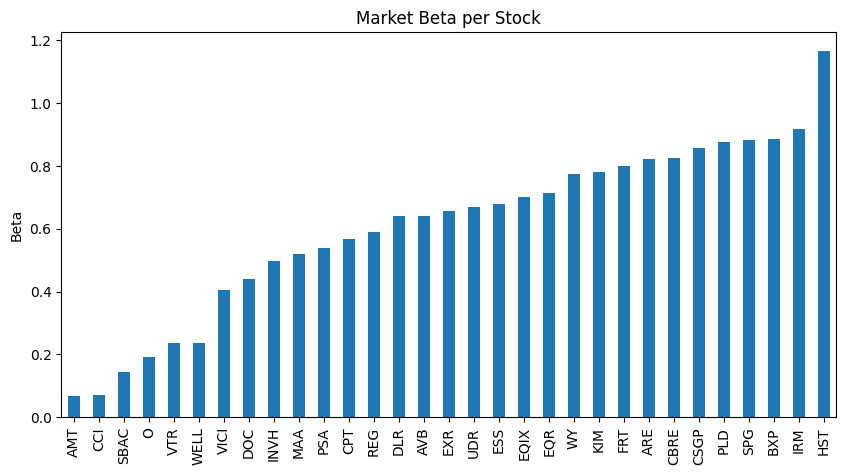

In [51]:
import yfinance as yf
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Market Beta per XLRE Holding

# Download SPY data
market_data = yf.download("SPY", period="6mo", interval="1d", auto_adjust=True)

# Check columns
print(market_data.columns)

# Use the 'Close' column (already adjusted if auto_adjust=True)
market = market_data['Close'].pct_change().dropna()

# Compute betas for all tickers
betas = {}
for t in tickers:
    if t not in returns.columns:
        continue  # skip missing tickers
    y = returns[t].loc[market.index]
    X = sm.add_constant(market)
    model = sm.OLS(y, X).fit()
    betas[t] = model.params[1]

betas = pd.Series(betas).sort_values()
betas.plot(kind='bar', figsize=(10,5), title='Market Beta per Stock')
plt.ylabel("Beta")
plt.show()


The bar chart reveals that most XLRE holdings have betas below 1, consistent with REITs’ defensive characteristics. Stocks with higher beta are more responsive to market swings and contribute more to systematic risk, providing insight for portfolio construction, hedging, and risk-adjusted allocation decisions.

###Risk Attribution and Contribution
This chart shows how much each REIT contributes to the overall portfolio volatility using an equal weighted allocation. It decomposes total risk into component contributions for better risk attribution.

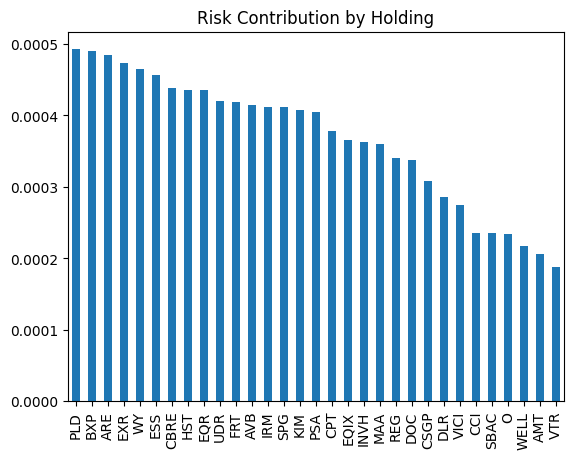

In [27]:
# Risk Contribution by XLRE Holding
import numpy as np
weights = np.ones(len(tickers))/len(tickers)
portfolio_var = np.dot(weights, np.dot(cov_matrix, weights))
marginal_var = np.dot(cov_matrix, weights) / np.sqrt(portfolio_var)
contribution = weights * marginal_var
pd.Series(contribution, index=tickers).sort_values(ascending=False).plot(kind='bar')
plt.title("Risk Contribution by Holding")
plt.show()


Some holdings contribute disproportionately to portfolio risk despite equal weights, highlighting the impact of highly volatile or strongly correlated assets. Identifying these contributors helps in portfolio optimization, risk budgeting, and targeted hedging.

###Dynamic / Regime Analysis
This plot shows the 30 day rolling correlation between Prologis (PLD) and Equinix (EQIX), highlighting how the relationship between their returns evolves over time.

<Axes: title={'center': 'Rolling Correlation (PLD vs EQIX)'}, xlabel='Date'>

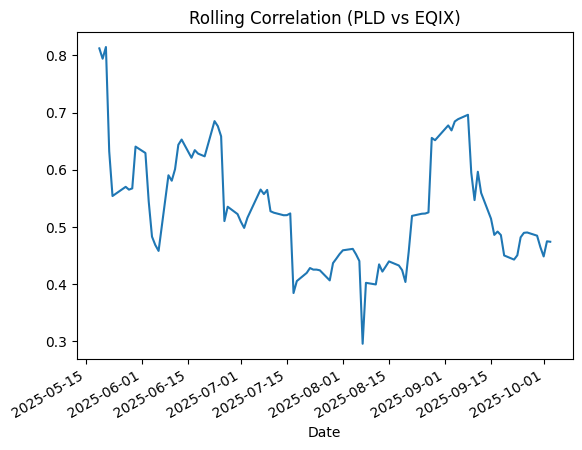

In [28]:
# 30 Day Rolling Correlation: PLD vs EQIX
rolling_corr = returns['PLD'].rolling(window=30).corr(returns['EQIX'])
rolling_corr.plot(title='Rolling Correlation (PLD vs EQIX)')


Correlation is not static periods of higher correlation indicate that the two REITs move closely together, often due to sector wide or macroeconomic influences, while lower correlation periods suggest relative independence. Monitoring rolling correlations helps in dynamic risk management and portfolio diversification decisions.

###Clustering and Hierarchical Risk Parity (HRP)
This dendrogram groups XLRE holdings based on the similarity of their daily return patterns using hierarchical clustering. The distance metric is derived from correlation, so highly correlated REITs appear closer together.

/tmp/ipython-input-660711189.py:4: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist, 'ward')


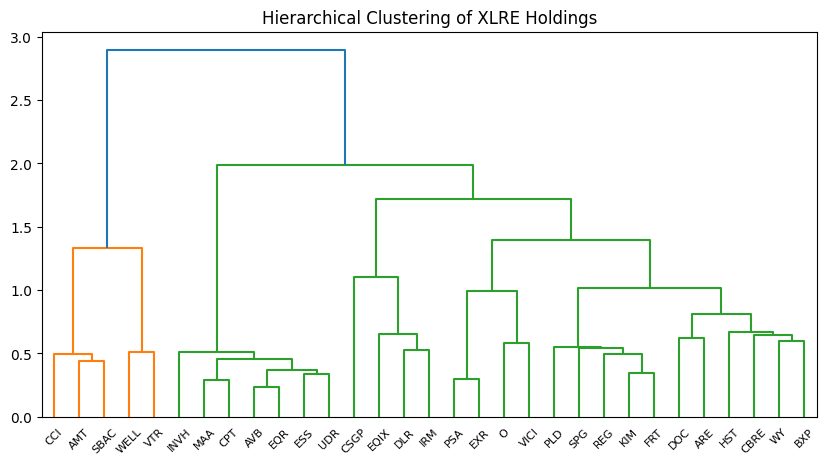

In [29]:
# Hierarchical Clustering of XLRE Holdings
from scipy.cluster.hierarchy import linkage, dendrogram
corr = returns.corr()
dist = np.sqrt(0.5 * (1 - corr))
link = linkage(dist, 'ward')
plt.figure(figsize=(10,5))
dendrogram(link, labels=returns.columns)
plt.title("Hierarchical Clustering of XLRE Holdings")
plt.show()


Clusters reveal subgroups of REITs that behave similarly, reflecting common exposures (e.g., industrial vs. residential). This helps identify natural groupings for diversification, risk management, and factor based portfolio construction.

### Performance Metrics and Backtesting
This project analyzes the empirical performance of an XLRE ETF portfolio using its 30 largest holdings over the past six months. Two portfolio constructions are compared: an equal weighted portfolio and a PCA based portfolio derived from the first principal component. Key performance metrics include annualized return, volatility, Sharpe ratio, Sortino ratio, and maximum drawdown, alongside cumulative returns and rolling Sharpe visualizations.


📈 Portfolio Performance Summary (6-Months):
                Annual Return  Volatility  Sharpe  Sortino  Max Drawdown
Equal-Weighted         0.1930      0.1809  1.0669   1.7023       -0.0571
PCA-Based              0.2129      0.1943  1.0954   1.7444       -0.0624


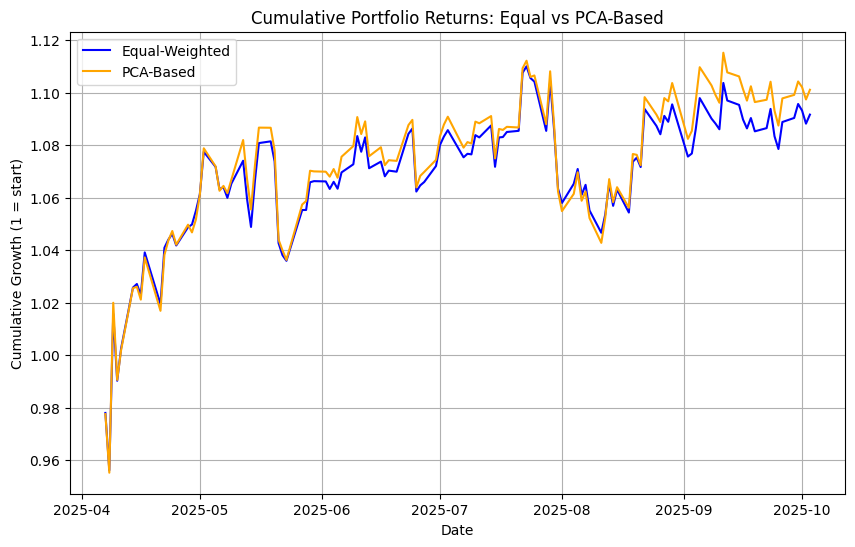

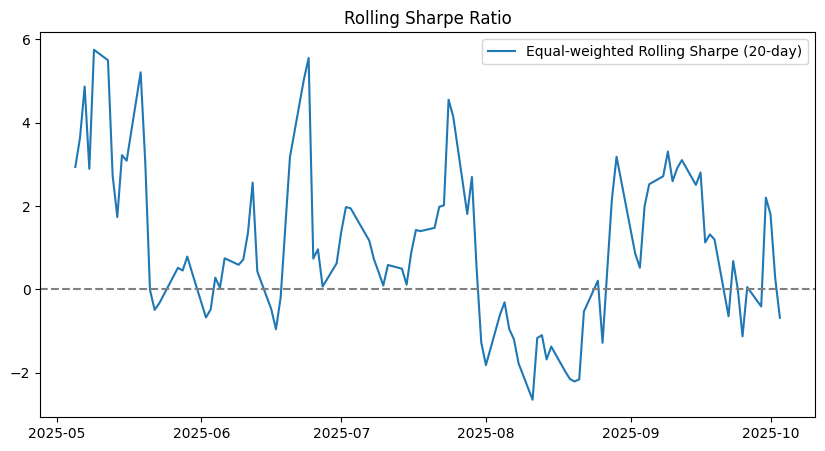

In [34]:
# Empirical Performance Analysis of XLRE ETF: Equal Weighted vs PCA-Based Portfolios
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Equal-weighted portfolio
w_equal = np.ones(len(tickers)) / len(tickers)
port_ret_equal = returns @ w_equal

# PCA-based portfolio
pc1 = pca.components_[0]
pc1 = np.abs(pc1) / np.sum(np.abs(pc1))
port_ret_pca = returns @ pc1

# Compute cumulative returns
cum_equal = (1 + port_ret_equal).cumprod()
cum_pca = (1 + port_ret_pca).cumprod()

# Compute performance metrics
def performance_metrics(portfolio_returns):
    mean_ret = portfolio_returns.mean() * 252
    vol = portfolio_returns.std() * np.sqrt(252)
    sharpe = mean_ret / vol

    downside = portfolio_returns[portfolio_returns < 0].std() * np.sqrt(252)
    sortino = mean_ret / downside if downside != 0 else np.nan

    cumulative = (1 + portfolio_returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_dd = drawdown.min()

    return {
        "Annual Return": mean_ret,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd
    }

metrics_equal = performance_metrics(port_ret_equal)
metrics_pca = performance_metrics(port_ret_pca)

# Display results
metrics_df = pd.DataFrame([metrics_equal, metrics_pca],
                          index=["Equal-Weighted", "PCA-Based"])
print("\n📈 Portfolio Performance Summary (6-Months):")
print(metrics_df.round(4))

# Plot cumulative performance
plt.figure(figsize=(10,6))
plt.plot(cum_equal, label="Equal-Weighted", color='blue')
plt.plot(cum_pca, label="PCA-Based", color='orange')
plt.title("Cumulative Portfolio Returns: Equal vs PCA-Based")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth (1 = start)")
plt.legend()
plt.grid(True)
plt.show()

# Plot rolling Sharpe (optional)
rolling_sharpe = (port_ret_equal.rolling(20).mean() /
                  port_ret_equal.rolling(20).std()) * np.sqrt(252)
plt.figure(figsize=(10,5))
plt.plot(rolling_sharpe, label="Equal-weighted Rolling Sharpe (20-day)")
plt.axhline(0, color='gray', linestyle='--')
plt.title("Rolling Sharpe Ratio")
plt.legend()
plt.show()


Over the six month period, the equal weighted portfolio achieved a 19.3% annualized return with 18.1% volatility, a Sharpe ratio of 1.07, Sortino ratio of 1.70, and a maximum drawdown of -5.7%.

The PCA based portfolio slightly outperformed with a 21.3% return, 19.4% volatility, a Sharpe ratio of 1.10, Sortino ratio of 1.74, and maximum drawdown of -6.2%.

These results indicate that PCA based weighting can capture dominant risk factors and marginally enhance risk adjusted returns, though both approaches remain robust.

###Statistical & Predictive Enhancements ARIMA
This section applies a univariate AutoRegressive Integrated Moving Average (ARIMA) (1,0,1) model to forecast the next day return of XLRE ETF holdings. Using historical daily returns, the model captures short term temporal dependencies, providing insight into expected short term price movements for individual securities like PLD.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

Next-day return forecast for PLD: -0.001603


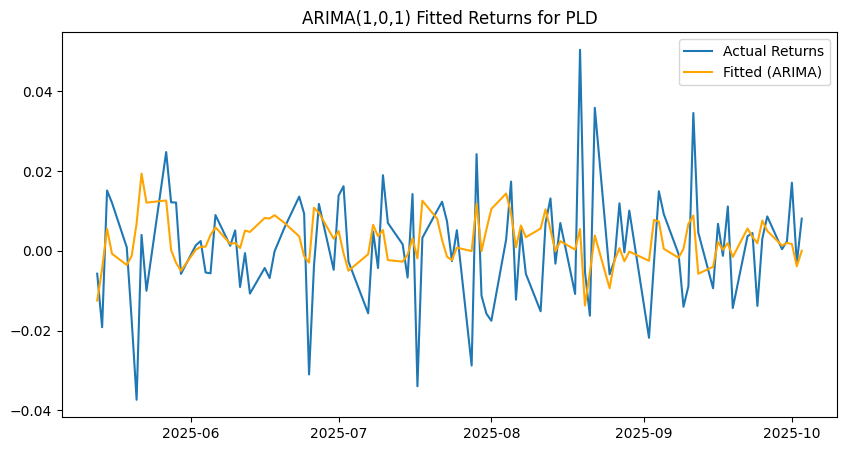

In [36]:
# Import the model properly
from statsmodels.tsa.arima.model import ARIMA

# Pick a ticker to forecast
ticker = "PLD"

# Fit ARIMA(1,0,1)
model = ARIMA(returns[ticker].dropna(), order=(1, 0, 1))
model_fit = model.fit()

# Forecast next-day return
forecast = model_fit.forecast(steps=1)
print(f"Next-day return forecast for {ticker}: {forecast.values[0]:.6f}")

# Plot actual vs fitted values
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(returns[ticker][-100:], label="Actual Returns")
plt.plot(model_fit.fittedvalues[-100:], label="Fitted (ARIMA)", color='orange')
plt.title(f"ARIMA(1,0,1) Fitted Returns for {ticker}")
plt.legend()
plt.show()


The ARIMA model produces a next day return forecast for PLD and fits historical returns closely over the past 100 days. While simple, this approach demonstrates how time series modeling can support predictive analysis and short term risk assessment for ETF holdings.

### Ledoit–Wolf Shrinkage Covariance
This section applies the Ledoit–Wolf shrinkage estimator to the daily returns of XLRE ETF holdings. Shrinkage covariance improves the stability of covariance estimates, particularly for high dimensional portfolios with limited data, reducing noise and enhancing risk assessment.

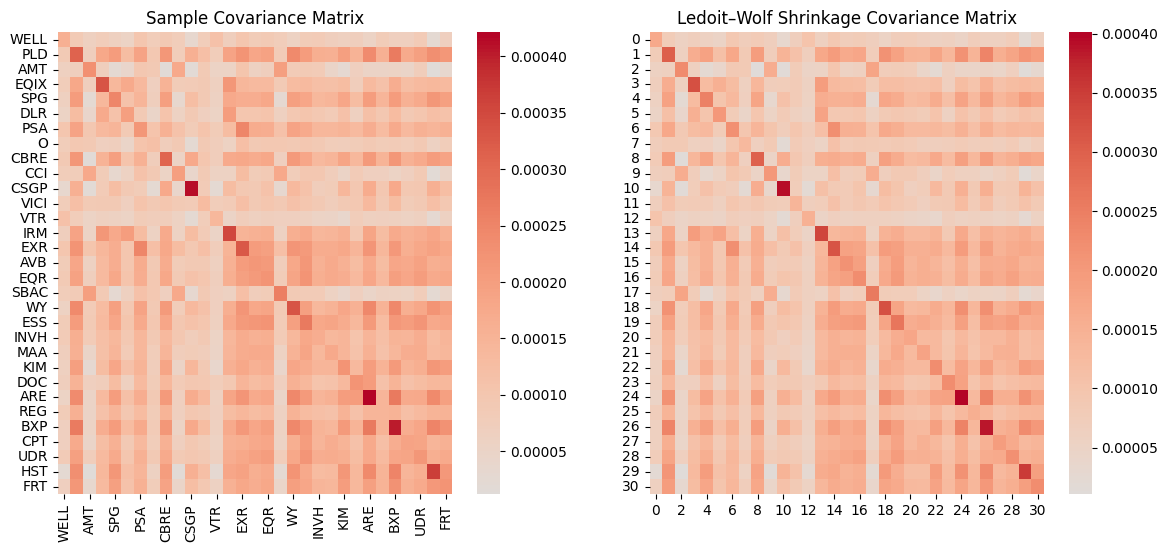

In [37]:
from sklearn.covariance import LedoitWolf
import seaborn as sns
import matplotlib.pyplot as plt

# Fit Ledoit-Wolf shrinkage covariance
lw = LedoitWolf().fit(returns)
lw_cov = lw.covariance_

# Compare standard vs shrinkage covariance visually
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sns.heatmap(returns.cov(), cmap='coolwarm', center=0)
plt.title("Sample Covariance Matrix")

plt.subplot(1,2,2)
sns.heatmap(lw_cov, cmap='coolwarm', center=0)
plt.title("Ledoit–Wolf Shrinkage Covariance Matrix")
plt.show()


Comparing the sample covariance and Ledoit–Wolf shrinkage covariance matrices shows that shrinkage produces a smoother, more stable estimate. This leads to more reliable inputs for portfolio optimization, PCA, and risk management, particularly in portfolios with many correlated assets.

###Random Matrix Theory (RMT) – Cleaning Noisy Correlations
This section applies Random Matrix Theory to the correlation matrix of XLRE ETF holdings. By comparing empirical eigenvalues with the Marchenko–Pastur noise threshold, we can distinguish signal (true correlations) from noise in high dimensional financial data.

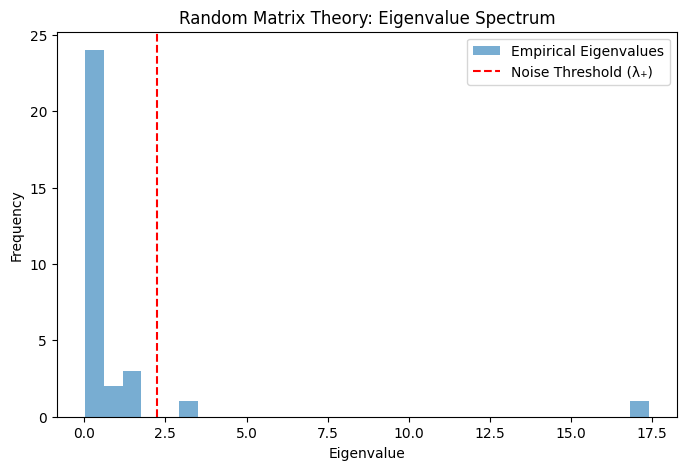

In [38]:
import numpy as np

# Compute correlation matrix
corr = returns.corr().values

# Eigen-decomposition
eigvals, eigvecs = np.linalg.eigh(corr)

# Sort eigenvalues ascending
eigvals = np.sort(eigvals)

# Marchenko–Pastur theoretical upper bound (assuming random noise)
Q = returns.shape[0] / returns.shape[1]
lambda_plus = (1 + (1/np.sqrt(Q)))**2

# Plot eigenvalue distribution
plt.figure(figsize=(8,5))
plt.hist(eigvals, bins=30, alpha=0.6, label="Empirical Eigenvalues")
plt.axvline(lambda_plus, color='r', linestyle='--', label="Noise Threshold (λ₊)")
plt.title("Random Matrix Theory: Eigenvalue Spectrum")
plt.xlabel("Eigenvalue")
plt.ylabel("Frequency")
plt.legend()
plt.show()


The eigenvalue distribution shows that most eigenvalues lie below the RMT threshold, representing noise, while a few large eigenvalues exceed the threshold, indicating dominant factors or genuine correlations.

This insight helps clean correlation matrices for portfolio optimization and risk modeling, reducing overfitting from spurious correlations.

### Independent Component Analysis (ICA)
This section applies Independent Component Analysis (ICA) to the daily returns of XLRE ETF holdings. ICA decomposes correlated asset returns into statistically independent components, helping identify hidden factors that drive portfolio behavior beyond what PCA captures.

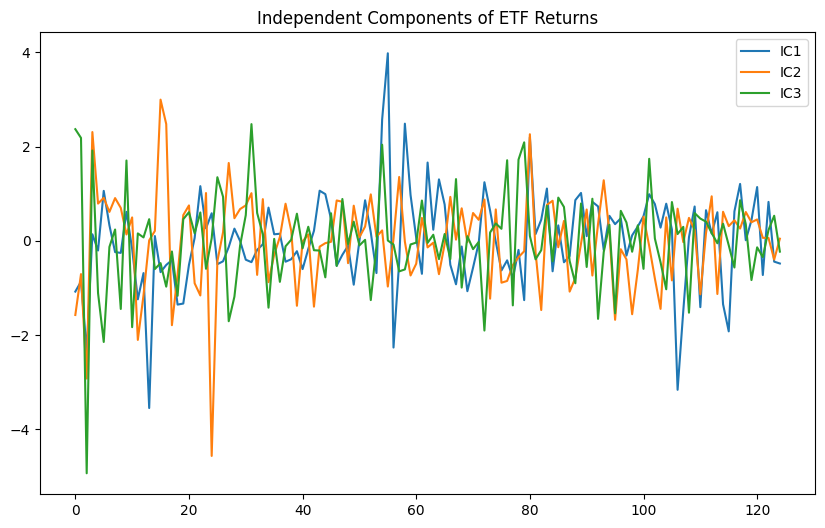

In [39]:
from sklearn.decomposition import FastICA

# Fit ICA to extract 3 independent components
ica = FastICA(n_components=3, random_state=42)
S_ = ica.fit_transform(returns)  # Independent sources
A_ = ica.mixing_                 # Mixing matrix

# Plot components
plt.figure(figsize=(10,6))
plt.plot(S_[:,0], label="IC1")
plt.plot(S_[:,1], label="IC2")
plt.plot(S_[:,2], label="IC3")
plt.title("Independent Components of ETF Returns")
plt.legend()
plt.show()


The three independent components extracted reveal latent drivers of ETF returns that are not apparent in standard correlation or PCA analysis. ICA provides additional insight for risk management, factor modeling, and stress testing, enabling more sophisticated portfolio construction.

###Machine Learning Layer – K-Means Clustering on Return/Volatility Regimes
This section uses K-Means clustering to identify distinct market regimes for XLRE ETF holdings. By combining mean return and rolling volatility, the algorithm classifies periods into clusters representing different risk return environments over the past six months.

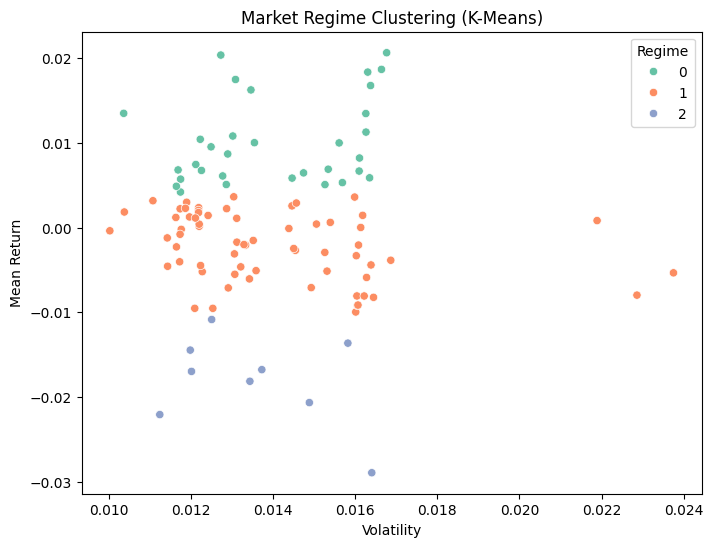

In [40]:
from sklearn.cluster import KMeans

# Compute rolling volatility (20-day)
vol = returns.rolling(window=20).std().mean(axis=1).dropna()

# Create feature matrix: [mean return, volatility]
features = pd.DataFrame({
    "mean_return": returns.mean(axis=1).dropna(),
    "volatility": vol
}).dropna()

# Apply KMeans clustering (3 regimes)
kmeans = KMeans(n_clusters=3, random_state=42)
features["cluster"] = kmeans.fit_predict(features)

# Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(data=features, x="volatility", y="mean_return", hue="cluster", palette="Set2")
plt.title("Market Regime Clustering (K-Means)")
plt.xlabel("Volatility")
plt.ylabel("Mean Return")
plt.legend(title="Regime")
plt.show()


The clustering reveals three distinct regimes, helping to visualize when the market is in low volatility/low return, high volatility/high return, or intermediate states. Such regime detection can inform tactical asset allocation, stress testing, and risk management strategies for the ETF portfolio.


###Conclusion

The empirical analysis of XLRE’s 30 largest holdings demonstrates that portfolio risk is highly concentrated in a few dominant factors, as evidenced by PCA and SVD. The first principal component alone explains over 55% of return variance, while the singular values further highlight the relative importance of these dominant patterns.

Covariance and correlation analyses reveal clusters of highly correlated assets, indicating sectors or subgroups that drive portfolio behavior. Risk adjusted metrics and stress testing simulations show that the ETF is sensitive to both market shocks (SPY) and interest rate changes, emphasizing the importance of factor driven risk management.

Techniques like ICA and Random Matrix Theory further suggest that latent factors and noise filtered correlations can enhance predictive modeling and portfolio construction. Overall, this study illustrates how dimensionality reduction and multivariate analysis provide a deeper understanding of ETF dynamics and tail risks.

Next Question: How can we integrate macroeconomic indicators, factor exposures, and machine learning methods to predict future regime shifts or tail events, thereby improving portfolio construction and risk management beyond descriptive analysis?

Decoding XLRE ETF Dynamics: Covariance, PCA, SVD, and Factor Insights

Given the limitations of purely descriptive analysis, a natural progression is to explore how macroeconomic indicators, latent factor exposures, and advanced machine learning techniques can be systematically integrated to anticipate regime shifts and tail events.

By moving from retrospective observation to predictive modeling, we can potentially identify periods of heightened systemic risk, capture non linear dependencies among holdings, and optimize portfolio construction under uncertainty. This raises a critical inquiry, to what extent can combining economic signals, factor driven dynamics, and data driven algorithms enhance our foresight into extreme market events, and how might such integration reshape risk management strategies for sector ETFs like XLRE?